In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/Clean_Dataset.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473 entries, 0 to 1472
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1473 non-null   object 
 1   Age                       1473 non-null   int64  
 2   AgeGroup                  1473 non-null   object 
 3   Attrition                 1473 non-null   object 
 4   BusinessTravel            1473 non-null   object 
 5   DailyRate                 1473 non-null   int64  
 6   Department                1473 non-null   object 
 7   DistanceFromHome          1473 non-null   int64  
 8   Education                 1473 non-null   int64  
 9   EducationField            1473 non-null   object 
 10  EmployeeNumber            1473 non-null   int64  
 11  EnvironmentSatisfaction   1473 non-null   int64  
 12  Gender                    1473 non-null   object 
 13  HourlyRate                1473 non-null   int64  
 14  JobInvol

In [4]:
df.describe().T.sort_values(
    by='std',
    ascending=False
)

,count,mean,std,min,25%,50%,75%,max
MonthlyRate,1473.0,14321.376103,7115.540450,2094.0,8053.0,14242.0,20467.0,26999.0
MonthlyIncome,1473.0,6500.228785,4706.053923,1009.0,2911.0,4908.0,8380.0,19999.0
EmployeeNumber,1473.0,1026.975560,603.223162,1.0,492.0,1024.0,1558.0,2068.0
DailyRate,1473.0,802.659878,403.245460,102.0,465.0,802.0,1157.0,1499.0
HourlyRate,1473.0,65.833673,20.350032,30.0,48.0,66.0,83.0,100.0
Age,1473.0,36.917176,9.130690,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1473.0,9.196877,8.107754,1.0,2.0,7.0,14.0,29.0
TotalWorkingYears,1473.0,11.277665,7.776228,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1473.0,7.004752,6.121004,0.0,3.0,5.0,9.0,40.0
PercentSalaryHike,1473.0,15.212492,3.657230,11.0,12.0,14.0,18.0,25.0


1. Employee age ranges from 18 to 60 years, with an average age of approximately
37 years. Most employees fall between 30 and 43 years of age.


2. Employees have an average of 11.3 years of total work experience, with some employees having up to 40 years of experience.


3. Employees have worked at the company for an average of 7 years. Some employees are newly joined, while a few have remained with the company for as long as 40 years.


4. Monthly income varies significantly across employees, ranging from 1,009 to 19,999. This suggests the workforce contains multiple job levels and salary bands.


5. Job Satisfaction, Environment Satisfaction, Relationship Satisfaction, and Work-Life Balance scores are generally centered around the middle to higher ratings.



In [5]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['EmpID', 'AgeGroup', 'Attrition', 'BusinessTravel', 'Department',
       'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'SalarySlab',
       'OverTime'],
      dtype='object')

In [6]:
df['Department'].value_counts()

,count
Department,
Research & Development,963
Sales,447
Human Resources,63


In [7]:
df['Department'].value_counts(normalize=True)*100

,proportion
Department,
Research & Development,65.376782
Sales,30.346232
Human Resources,4.276986


In [8]:
df['Gender'].value_counts()

,count
Gender,
Male,884
Female,589


In [9]:
df['BusinessTravel'].value_counts()

,count
BusinessTravel,
Travel_Rarely,1038
Travel_Frequently,278
Non-Travel,150
TravelRarely,7


In [10]:
df['JobRole'].value_counts()

,count
JobRole,
Sales Executive,326
Research Scientist,292
Laboratory Technician,260
Manufacturing Director,145
Healthcare Representative,132
Manager,102
Sales Representative,84
Research Director,80
Human Resources,52


In [11]:
for col in cat_cols:
    print("\n",col)
    print(df[col].value_counts())


 EmpID
EmpID
RM1465    2
RM1467    2
RM1466    2
RM1084    1
RM1046    1
         ..
RM657     1
RM642     1
RM638     1
RM627     1
RM940     1
Name: count, Length: 1470, dtype: int64

 AgeGroup
AgeGroup
26-35    607
36-45    470
46-55    226
18-25    123
55+       47
Name: count, dtype: int64

 Attrition
Attrition
No     1236
Yes     237
Name: count, dtype: int64

 BusinessTravel
BusinessTravel
Travel_Rarely        1038
Travel_Frequently     278
Non-Travel            150
TravelRarely            7
Name: count, dtype: int64

 Department
Department
Research & Development    963
Sales                     447
Human Resources            63
Name: count, dtype: int64

 EducationField
EducationField
Life Sciences       606
Medical             466
Marketing           159
Technical Degree    132
Other                83
Human Resources      27
Name: count, dtype: int64

 Gender
Gender
Male      884
Female    589
Name: count, dtype: int64

 JobRole
JobRole
Sales Executive              326
Resear

In [12]:
df['BusinessTravel'].unique()

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel', 'TravelRarely'],
      dtype=object)

In [13]:
df['BusinessTravel'] = df['BusinessTravel'].replace(
    {'TravelRarely':'Travel_Rarely'}
)

In [14]:
df['BusinessTravel'].value_counts()

,count
BusinessTravel,
Travel_Rarely,1045
Travel_Frequently,278
Non-Travel,150


In [15]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].unique())


EmpID
['RM297' 'RM302' 'RM458' ... 'RM537' 'RM880' 'RM1210']

AgeGroup
['18-25' '26-35' '36-45' '46-55' '55+']

Attrition
['Yes' 'No']

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department
['Research & Development' 'Sales' 'Human Resources']

EducationField
['Life Sciences' 'Medical' 'Marketing' 'Technical Degree' 'Other'
 'Human Resources']

Gender
['Male' 'Female']

JobRole
['Laboratory Technician' 'Sales Representative' 'Research Scientist'
 'Human Resources' 'Manufacturing Director' 'Sales Executive'
 'Healthcare Representative' 'Research Director' 'Manager']

MaritalStatus
['Single' 'Divorced' 'Married']

SalarySlab
['Upto 5k' '5k-10k' '10k-15k' '15k+']

OverTime
['No' 'Yes']


In [16]:
df['EmpID'].nunique()

1470

In [17]:
df[df['EmpID'].duplicated(keep=False)].sort_values('EmpID')

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
161,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,3,4,0,5,2,3,4,2,0,0.0
162,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,3,4,0,5,2,3,4,2,0,5.0
798,RM1466,36,36-45,No,Travel_Frequently,884,Research & Development,23,2,Medical,...,3,3,1,17,3,3,5,2,0,3.0
799,RM1466,36,36-45,No,Travel_Frequently,884,Research & Development,23,2,Medical,...,3,3,1,17,3,3,5,2,0,2.0
949,RM1467,39,36-45,No,Travel_Rarely,613,Research & Development,6,1,Medical,...,3,1,1,9,5,3,7,7,1,7.0
950,RM1467,39,36-45,No,Travel_Rarely,613,Research & Development,6,1,Medical,...,3,1,1,9,5,3,7,7,1,1.0


In [18]:
duplicate_emp = df[df['EmpID'].duplicated(keep=False)]

for emp in duplicate_emp['EmpID'].unique():
    display(
        duplicate_emp[duplicate_emp['EmpID']==emp]
    )

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
161,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,3,4,0,5,2,3,4,2,0,0.0
162,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,3,4,0,5,2,3,4,2,0,5.0


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
798,RM1466,36,36-45,No,Travel_Frequently,884,Research & Development,23,2,Medical,...,3,3,1,17,3,3,5,2,0,3.0
799,RM1466,36,36-45,No,Travel_Frequently,884,Research & Development,23,2,Medical,...,3,3,1,17,3,3,5,2,0,2.0


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
949,RM1467,39,36-45,No,Travel_Rarely,613,Research & Development,6,1,Medical,...,3,1,1,9,5,3,7,7,1,7.0
950,RM1467,39,36-45,No,Travel_Rarely,613,Research & Development,6,1,Medical,...,3,1,1,9,5,3,7,7,1,1.0


In [19]:
df = df.sort_values(
    by='YearsWithCurrManager',
    ascending=False
)

df = df.drop_duplicates(
    subset='EmpID',
    keep='first'
)

In [20]:
df['EmpID'].nunique()

1470

In [21]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [23]:
attrition_rate = (
    df['Attrition'].value_counts(normalize=True)['Yes']
) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


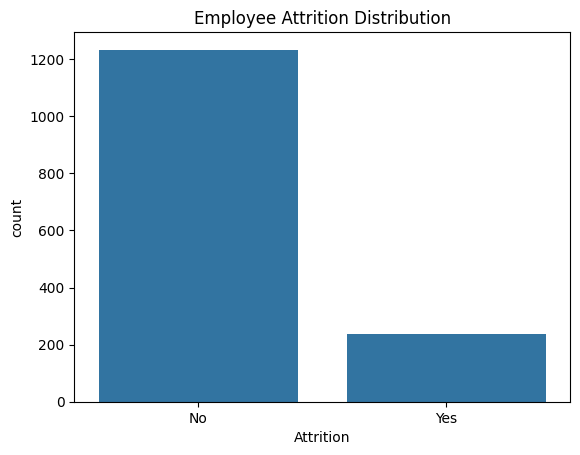

In [24]:
sns.countplot(
    data=df,
    x='Attrition'
)

plt.title('Employee Attrition Distribution')
plt.show()

Observation
Out of 1,470 employees, 237 employees have left the organization, resulting in

1.   Out of 1,470 employees, 237 employees have left the organization, resulting in an attrition rate of 16.12%.
2.   The majority of employees (83.88%) remain with the company, indicating overall workforce stability.

However, an attrition rate above 16% suggests that employee retention remains a significant business concern and warrants further investigation into potential drivers of attrition.

In [25]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

dept_attrition

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [26]:
dept_attrition_pct = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

dept_attrition_pct.round(2)

Attrition,No,Yes
Department,,
Human Resources,80.95,19.05
Research & Development,86.16,13.84
Sales,79.37,20.63


In [27]:
pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [28]:
pd.crosstab(
    df['SalarySlab'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
SalarySlab,,
10k-15k,86.486486,13.513514
15k+,96.240602,3.759398
5k-10k,88.863636,11.136364
Upto 5k,78.237650,21.762350


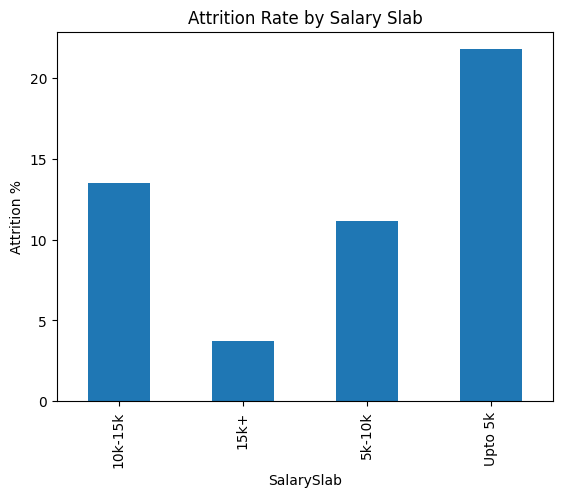

In [29]:
salary_attr = pd.crosstab(
    df['SalarySlab'],
    df['Attrition'],
    normalize='index'
)*100

salary_attr['Yes'].plot(kind='bar')
plt.ylabel('Attrition %')
plt.title('Attrition Rate by Salary Slab')
plt.show()

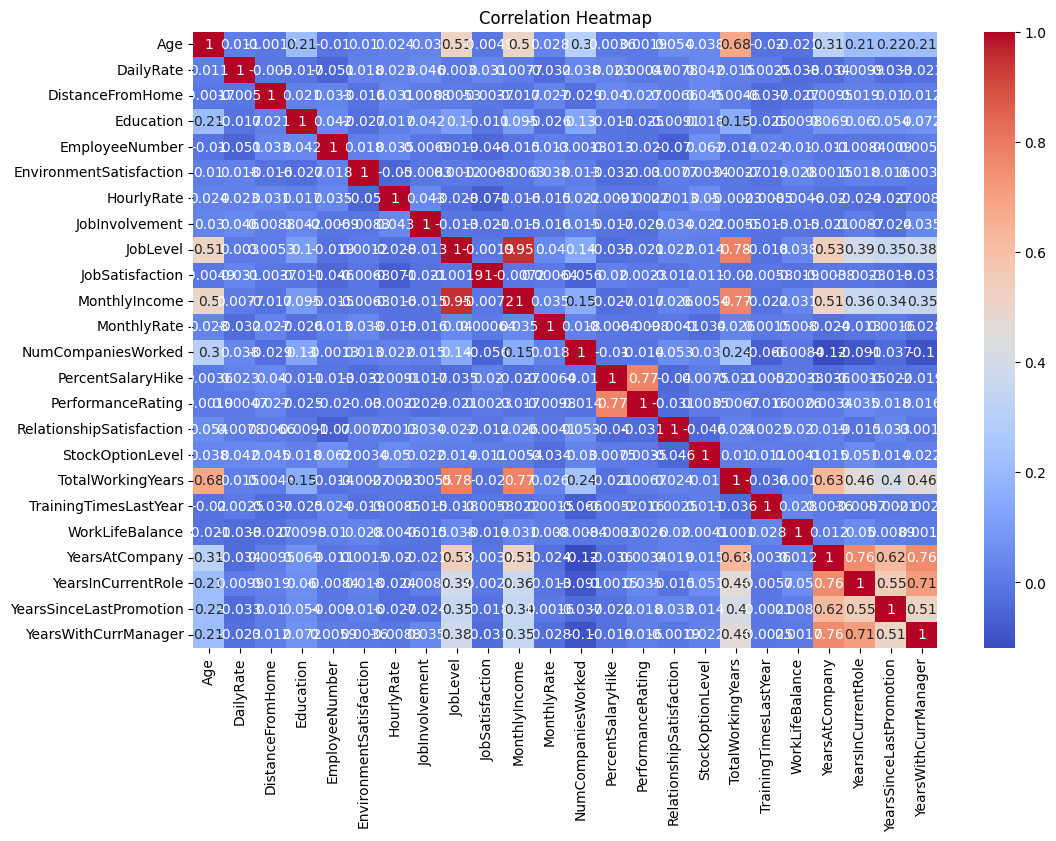

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [31]:
pd.crosstab(
    [df['OverTime'], df['SalarySlab']],
    df['Attrition'],
    normalize='index'
)*100

Attrition                   No        Yes
OverTime SalarySlab                      
No       10k-15k     88.541667  11.458333
         15k+        98.000000   2.000000
         5k-10k      92.993631   7.006369
         Upto 5k     86.213235  13.786765
Yes      10k-15k     82.692308  17.307692
         15k+        90.909091   9.090909
         5k-10k      78.571429  21.428571
         Upto 5k     57.073171  42.926829

In [32]:
pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


In [34]:
job_ot = pd.crosstab(
    [df['JobRole'], df['OverTime']],
    df['Attrition'],
    normalize='index'
)*100

job_ot.sort_values('Yes', ascending=False)

,Attrition,No,Yes
JobRole,OverTime,,
Sales Representative,Yes,33.333333,66.666667
Laboratory Technician,Yes,50.000000,50.000000
Human Resources,Yes,61.538462,38.461538
Research Scientist,Yes,65.979381,34.020619
Sales Executive,Yes,67.021277,32.978723
Sales Representative,No,71.186441,28.813559
Human Resources,No,82.051282,17.948718
Laboratory Technician,No,84.263959,15.736041
Manager,Yes,85.185185,14.814815


In [35]:
pd.crosstab(
    [df['JobRole'], df['OverTime']],
    df['Attrition']
).sort_values('Yes', ascending=False)

Attrition                            No  Yes
JobRole                   OverTime          
Research Scientist        Yes        64   33
Laboratory Technician     Yes        31   31
Sales Executive           Yes        63   31
Laboratory Technician     No        166   31
Sales Executive           No        206   26
Sales Representative      No         42   17
                          Yes         8   16
Research Scientist        No        181   14
Human Resources           No         32    7
Healthcare Representative No         87    7
Manufacturing Director    No        100    6
Human Resources           Yes         8    5
Manufacturing Director    Yes        35    4
Manager                   Yes        23    4
Healthcare Representative Yes        35    2
Manager                   No         74    1
Research Director         No         56    1
                          Yes        22    1

Sales Representatives working overtime exhibit the highest attrition rate (66.67%), although the employee group is relatively small. Among larger employee segments, Laboratory Technicians (50%) and Research Scientists (34%) working overtime also show elevated attrition rates.

In [36]:
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [37]:
pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [38]:
pd.crosstab(
    df['AgeGroup'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
AgeGroup,,
18-25,64.227642,35.772358
26-35,80.858086,19.141914
36-45,90.811966,9.188034
46-55,88.495575,11.504425
55+,82.978723,17.021277


In [39]:
pd.crosstab(
    df['MaritalStatus'],
    df['Attrition'],
    normalize='index'
)*100

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


1.  Overall attrition rate = 16.12%
2.  Overtime employees have 30.53% attrition vs 10.44% for non-overtime employees.
3.  Employees earning below 5k and working overtime show 42.93% attrition.
4.  Sales Representatives working overtime have 66.67% attrition.
5.  Employees aged 18-25 have the highest attrition rate (35.77%).
6.  Single employees show higher attrition (25.53%) than married employees (12.48%).
7.  Employees with poor work-life balance show 31.25% attrition.

